# LESSON 6.3: Restoration in the Presence of Noise — Spatial Filtering
## Image Restoration

In this lesson:
- When $H = 1$ (no blur), the degradation model simplifies to $g = f + \eta$
- Arithmetic mean filter
- Geometric mean filter
- Harmonic mean filter
- Contraharmonic mean filter and the role of order Q
- Order-statistic filters: median, max, min, midpoint, alpha-trimmed mean
- Comparison of all filters on different noise types

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Introduction: Noise-Only Degradation

When the degradation function $H$ is the identity (i.e., no blur), the degradation model simplifies to:

$$g(x,y) = f(x,y) + \eta(x,y)$$

In this case, **spatial filters** applied directly to $g(x,y)$ can reduce the noise.

### Two categories of spatial noise filters:

1. **Mean Filters**: Replace each pixel by a function of the mean of its neighborhood
2. **Order-Statistic Filters**: Replace each pixel based on the rank ordering of its neighborhood

### Notation:
- $S_{xy}$ = the set of pixels in the $m \times n$ neighborhood centered at $(x,y)$
- $g(r,c)$ = pixel values in that neighborhood (where $(r,c) \in S_{xy}$)

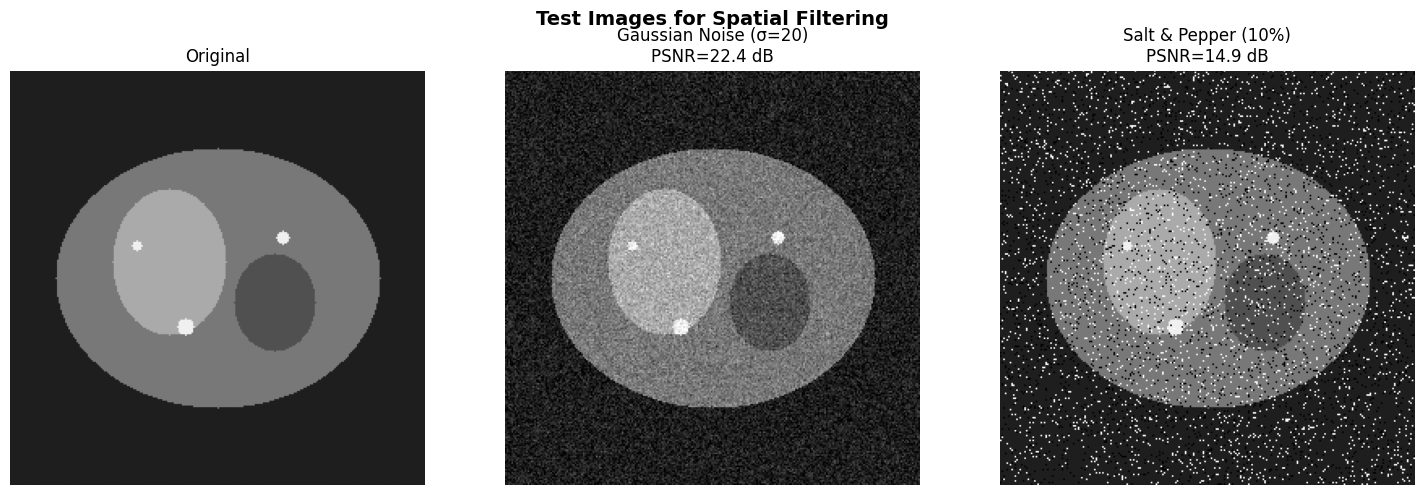

In [2]:
# Helper functions and test image creation

def create_test_image(size=256):
    """Create a synthetic biomedical phantom image."""
    img = np.ones((size, size), dtype=np.float64) * 30
    Y, X = np.mgrid[0:size, 0:size]
    cx, cy = size // 2, size // 2
    
    body = ((X - cx) / 100) ** 2 + ((Y - cy) / 80) ** 2 <= 1
    img[body] = 120
    
    organ1 = ((X - cx + 30) / 35) ** 2 + ((Y - cy + 10) / 45) ** 2 <= 1
    img[organ1] = 170
    
    organ2 = ((X - cx - 35) / 25) ** 2 + ((Y - cy - 15) / 30) ** 2 <= 1
    img[organ2] = 80
    
    for (sx, sy, sr) in [(cx-20, cy+30, 5), (cx+40, cy-25, 4), (cx-50, cy-20, 3)]:
        spot = (X - sx) ** 2 + (Y - sy) ** 2 <= sr ** 2
        img[spot] = 240
    
    return img


def add_gaussian_noise(image, sigma=20):
    """Add Gaussian noise with given standard deviation."""
    np.random.seed(42)
    return np.clip(image + np.random.normal(0, sigma, image.shape), 0, 255)


def add_salt_pepper_noise(image, prob_salt=0.05, prob_pepper=0.05):
    """Add salt-and-pepper noise."""
    np.random.seed(42)
    noisy = image.copy()
    total = image.size
    
    num_salt = int(prob_salt * total)
    coords = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255
    
    num_pepper = int(prob_pepper * total)
    coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    
    return noisy


def compute_psnr(original, restored):
    """Compute Peak Signal-to-Noise Ratio in dB."""
    mse = np.mean((original - restored) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(255.0 ** 2 / mse)


# Create test images
original = create_test_image(256)
noisy_gauss = add_gaussian_noise(original, sigma=20)
noisy_sp = add_salt_pepper_noise(original, 0.05, 0.05)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

axes[1].imshow(noisy_gauss, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Gaussian Noise (σ=20)\nPSNR={compute_psnr(original, noisy_gauss):.1f} dB', fontsize=12)
axes[1].axis('off')

axes[2].imshow(noisy_sp, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f'Salt & Pepper (10%)\nPSNR={compute_psnr(original, noisy_sp):.1f} dB', fontsize=12)
axes[2].axis('off')

plt.suptitle('Test Images for Spatial Filtering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Mean Filters

### 2.1 Arithmetic Mean Filter

$$\hat{f}(x,y) = \frac{1}{mn} \sum_{(r,c) \in S_{xy}} g(r,c)$$

- Simple averaging over the $m \times n$ neighborhood
- Reduces Gaussian noise effectively
- **Blurs edges** (every pixel is treated equally)

### 2.2 Geometric Mean Filter

$$\hat{f}(x,y) = \left[\prod_{(r,c) \in S_{xy}} g(r,c)\right]^{1/mn}$$

- Product of all pixels in the neighborhood, raised to the $1/mn$ power
- Achieves smoothing comparable to arithmetic mean
- Tends to **preserve detail better** than arithmetic mean

### 2.3 Harmonic Mean Filter

$$\hat{f}(x,y) = \frac{mn}{\sum_{(r,c) \in S_{xy}} \frac{1}{g(r,c)}}$$

- Works well for **salt noise** (bright impulses)
- **Fails for pepper noise** (dark pixels cause division by zero)
- Good for Gaussian noise as well

### 2.4 Contraharmonic Mean Filter

$$\hat{f}(x,y) = \frac{\sum_{(r,c) \in S_{xy}} g(r,c)^{Q+1}}{\sum_{(r,c) \in S_{xy}} g(r,c)^Q}$$

Where $Q$ is the **order** of the filter:
- $Q > 0$: eliminates **pepper noise** (dark impulses)
- $Q < 0$: eliminates **salt noise** (bright impulses)
- $Q = 0$: reduces to **arithmetic mean**
- $Q = -1$: reduces to **harmonic mean**

**Warning**: Cannot remove both salt AND pepper simultaneously!

In [3]:
# Implement all mean filters

def arithmetic_mean_filter(image, kernel_size=3):
    """
    Arithmetic mean filter: average of neighborhood.
    f_hat(x,y) = (1/mn) * sum(g(r,c))
    """
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    
    for i in range(M):
        for j in range(N):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = np.mean(region)
    
    return result


def geometric_mean_filter(image, kernel_size=3):
    """
    Geometric mean filter: (product of neighborhood)^(1/mn).
    """
    M, N = image.shape
    pad = kernel_size // 2
    # Add small constant to avoid log(0)
    padded = np.pad(np.maximum(image, 1e-10), pad, mode='reflect')
    result = np.zeros_like(image)
    mn = kernel_size * kernel_size
    
    for i in range(M):
        for j in range(N):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            # Use log domain for numerical stability
            result[i, j] = np.exp(np.mean(np.log(np.maximum(region, 1e-10))))
    
    return np.clip(result, 0, 255)


def harmonic_mean_filter(image, kernel_size=3):
    """
    Harmonic mean filter: mn / sum(1/g(r,c)).
    """
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(np.maximum(image, 1e-10), pad, mode='reflect')
    result = np.zeros_like(image)
    mn = kernel_size * kernel_size
    
    for i in range(M):
        for j in range(N):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = mn / np.sum(1.0 / np.maximum(region, 1e-10))
    
    return np.clip(result, 0, 255)


def contraharmonic_mean_filter(image, kernel_size=3, Q=1):
    """
    Contraharmonic mean filter of order Q.
    f_hat = sum(g^(Q+1)) / sum(g^Q)
    Q > 0: eliminates pepper noise
    Q < 0: eliminates salt noise
    """
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(np.maximum(image, 1e-10), pad, mode='reflect')
    result = np.zeros_like(image)
    
    for i in range(M):
        for j in range(N):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            numerator = np.sum(region ** (Q + 1))
            denominator = np.sum(region ** Q)
            if denominator > 1e-20:
                result[i, j] = numerator / denominator
            else:
                result[i, j] = image[i, j]
    
    return np.clip(result, 0, 255)


print("All mean filter functions defined successfully.")

All mean filter functions defined successfully.


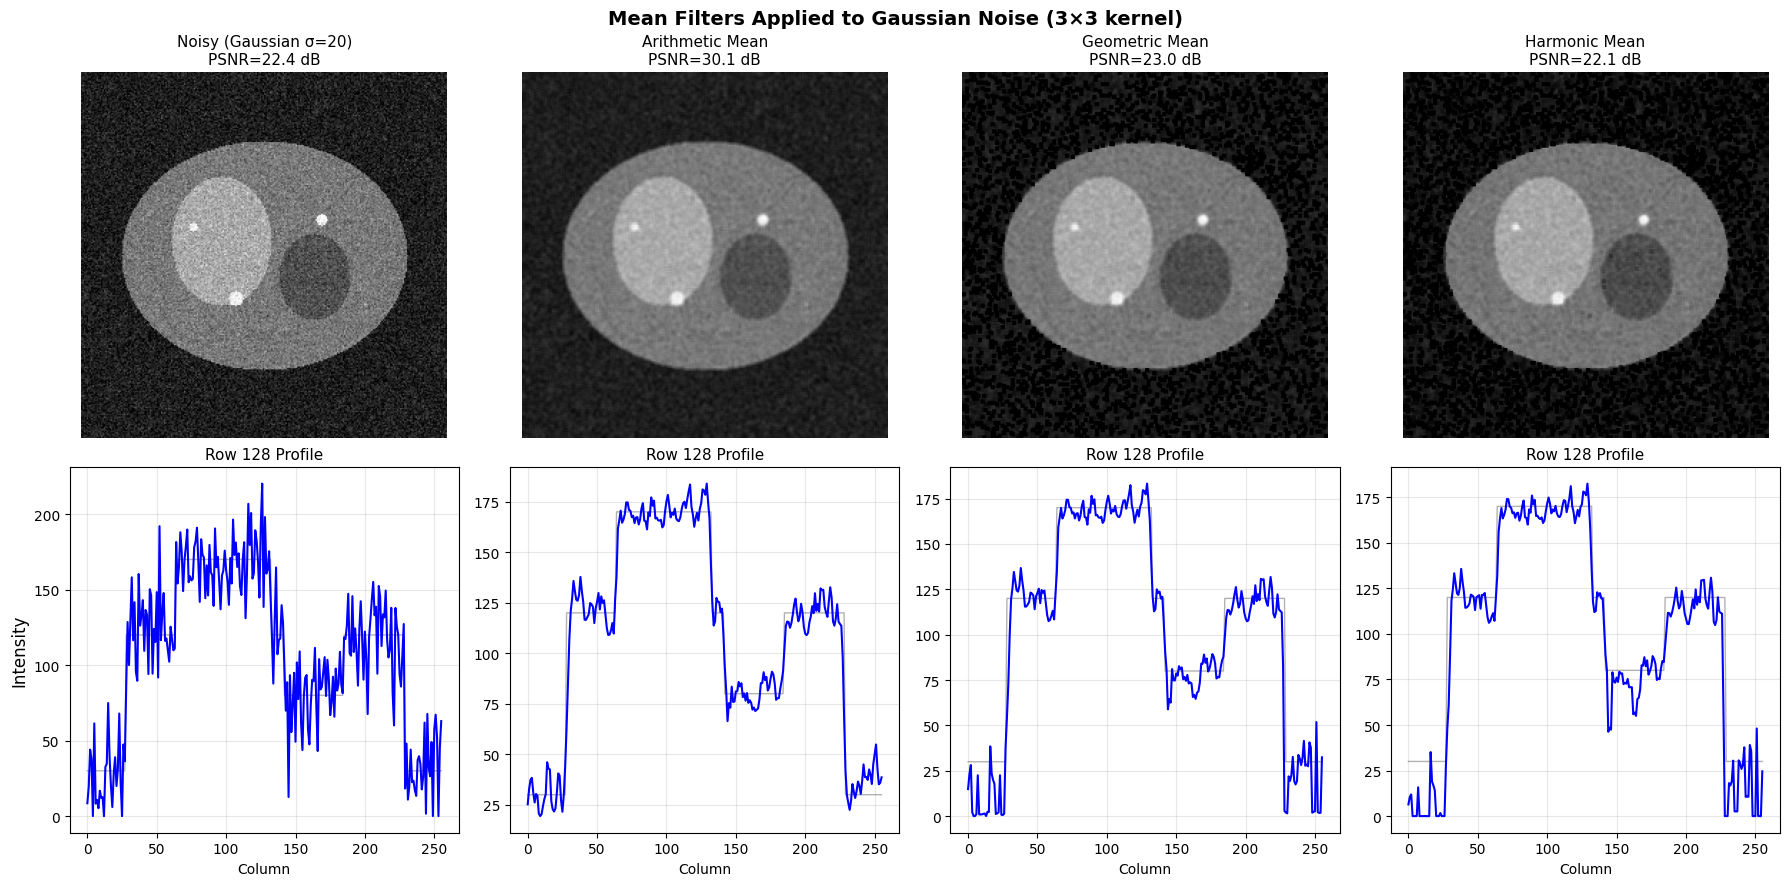

All three mean filters reduce Gaussian noise effectively.
Geometric mean tends to preserve detail slightly better.


In [4]:
# Apply mean filters to Gaussian noise

restored_arith = arithmetic_mean_filter(noisy_gauss, 3)
restored_geom = geometric_mean_filter(noisy_gauss, 3)
restored_harm = harmonic_mean_filter(noisy_gauss, 3)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

images = [noisy_gauss, restored_arith, restored_geom, restored_harm]
titles = ['Noisy (Gaussian σ=20)', 'Arithmetic Mean', 'Geometric Mean', 'Harmonic Mean']

for i, (img, title) in enumerate(zip(images, titles)):
    psnr = compute_psnr(original, img)
    
    axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'{title}\nPSNR={psnr:.1f} dB', fontsize=11)
    axes[0, i].axis('off')
    
    # Intensity profile
    row = 128
    axes[1, i].plot(original[row, :], 'k-', alpha=0.3, linewidth=1, label='Original')
    axes[1, i].plot(img[row, :], 'b-', linewidth=1.5)
    axes[1, i].set_title(f'Row {row} Profile', fontsize=11)
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].set_xlabel('Column')

axes[0, 0].set_ylabel('Filtered Image', fontsize=12)
axes[1, 0].set_ylabel('Intensity', fontsize=12)

plt.suptitle('Mean Filters Applied to Gaussian Noise (3×3 kernel)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("All three mean filters reduce Gaussian noise effectively.")
print("Geometric mean tends to preserve detail slightly better.")

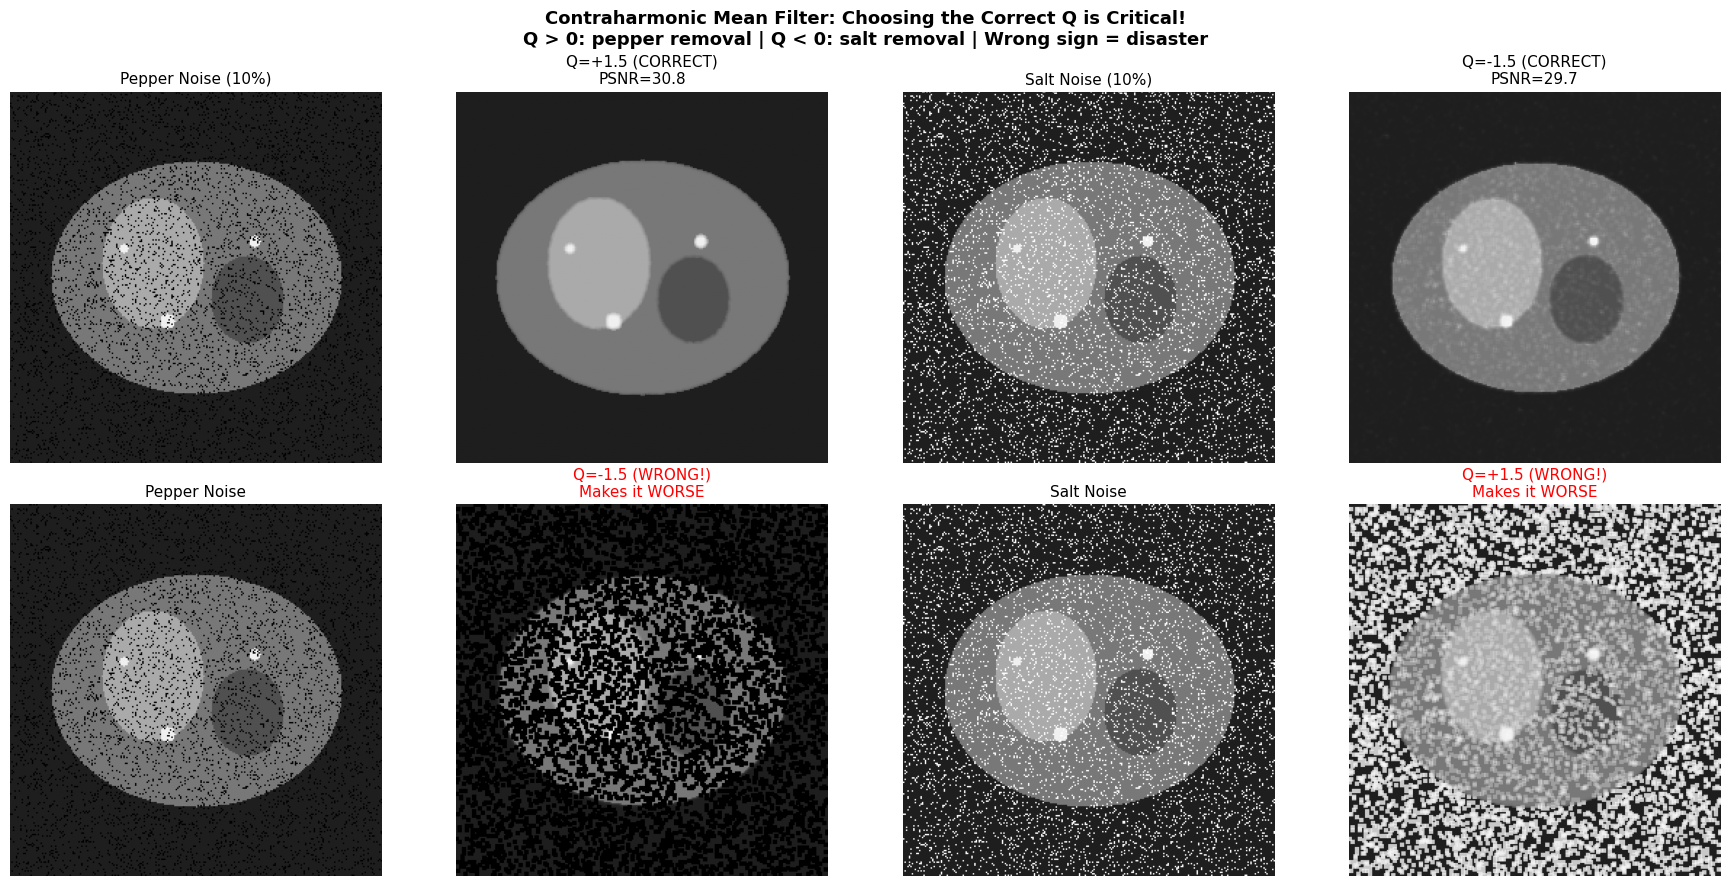

CRITICAL: Using the WRONG sign of Q makes the image WORSE, not better!
Q > 0 (positive): eliminates dark (pepper) noise
Q < 0 (negative): eliminates bright (salt) noise
Cannot handle both salt AND pepper simultaneously.


In [5]:
# Contraharmonic mean filter: Q > 0 for pepper, Q < 0 for salt

# Create images with salt-only and pepper-only noise
np.random.seed(42)
pepper_only = add_salt_pepper_noise(original, prob_salt=0, prob_pepper=0.1)
np.random.seed(42)
salt_only = add_salt_pepper_noise(original, prob_salt=0.1, prob_pepper=0)

# Apply contraharmonic filter
restored_pepper = contraharmonic_mean_filter(pepper_only, 3, Q=1.5)   # Q>0 for pepper
restored_salt = contraharmonic_mean_filter(salt_only, 3, Q=-1.5)      # Q<0 for salt

# Show the WRONG filter choice too
wrong_pepper = contraharmonic_mean_filter(pepper_only, 3, Q=-1.5)  # wrong!
wrong_salt = contraharmonic_mean_filter(salt_only, 3, Q=1.5)       # wrong!

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# Pepper noise row
axes[0, 0].imshow(pepper_only, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Pepper Noise (10%)', fontsize=11)
axes[0, 0].axis('off')

axes[0, 1].imshow(restored_pepper, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title(f'Q=+1.5 (CORRECT)\nPSNR={compute_psnr(original, restored_pepper):.1f}', fontsize=11)
axes[0, 1].axis('off')

# Salt noise row
axes[0, 2].imshow(salt_only, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('Salt Noise (10%)', fontsize=11)
axes[0, 2].axis('off')

axes[0, 3].imshow(restored_salt, cmap='gray', vmin=0, vmax=255)
axes[0, 3].set_title(f'Q=-1.5 (CORRECT)\nPSNR={compute_psnr(original, restored_salt):.1f}', fontsize=11)
axes[0, 3].axis('off')

# Wrong filter choices
axes[1, 0].imshow(pepper_only, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Pepper Noise', fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(wrong_pepper, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Q=-1.5 (WRONG!)\nMakes it WORSE', fontsize=11, color='red')
axes[1, 1].axis('off')

axes[1, 2].imshow(salt_only, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title('Salt Noise', fontsize=11)
axes[1, 2].axis('off')

axes[1, 3].imshow(wrong_salt, cmap='gray', vmin=0, vmax=255)
axes[1, 3].set_title('Q=+1.5 (WRONG!)\nMakes it WORSE', fontsize=11, color='red')
axes[1, 3].axis('off')

plt.suptitle('Contraharmonic Mean Filter: Choosing the Correct Q is Critical!\n'
             'Q > 0: pepper removal | Q < 0: salt removal | Wrong sign = disaster',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("CRITICAL: Using the WRONG sign of Q makes the image WORSE, not better!")
print("Q > 0 (positive): eliminates dark (pepper) noise")
print("Q < 0 (negative): eliminates bright (salt) noise")
print("Cannot handle both salt AND pepper simultaneously.")

---
## 3. Order-Statistic Filters

These filters are based on **ranking (ordering)** the pixel values in the neighborhood $S_{xy}$.

### 3.1 Median Filter

$$\hat{f}(x,y) = \text{median}_{(r,c) \in S_{xy}} \{g(r,c)\}$$

- Sort all $mn$ values and select the **middle value**
- **Excellent** for salt-and-pepper noise
- **Preserves edges** much better than mean filters
- Most popular order-statistic filter

### 3.2 Max Filter

$$\hat{f}(x,y) = \max_{(r,c) \in S_{xy}} \{g(r,c)\}$$

- Selects the **brightest** pixel in the neighborhood
- Useful for finding **brightest points** or removing **pepper (dark) noise**

### 3.3 Min Filter

$$\hat{f}(x,y) = \min_{(r,c) \in S_{xy}} \{g(r,c)\}$$

- Selects the **darkest** pixel in the neighborhood
- Useful for removing **salt (bright) noise**

### 3.4 Midpoint Filter

$$\hat{f}(x,y) = \frac{1}{2}\left[\max_{S_{xy}}\{g\} + \min_{S_{xy}}\{g\}\right]$$

- Average of max and min values
- Works best for **uniform** and **Gaussian** noise

### 3.5 Alpha-Trimmed Mean Filter

$$\hat{f}(x,y) = \frac{1}{mn - d} \sum_{(r,c) \in S_{xy}} g_r(r,c)$$

Where $g_r$ represents the remaining pixels after removing the $d/2$ lowest and $d/2$ highest values:
- $d = 0$: arithmetic mean filter
- $d = mn - 1$: median filter
- Intermediate $d$: **combination** of mean and median behavior
- Useful for **mixed noise** (e.g., Gaussian + salt-and-pepper)

In [6]:
# Implement order-statistic filters

def median_filter(image, kernel_size=3):
    """Median filter: select the median value from the neighborhood."""
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    
    for i in range(M):
        for j in range(N):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = np.median(region)
    
    return result


def max_filter(image, kernel_size=3):
    """Max filter: select the maximum value from the neighborhood."""
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    
    for i in range(M):
        for j in range(N):
            result[i, j] = np.max(padded[i:i+kernel_size, j:j+kernel_size])
    
    return result


def min_filter(image, kernel_size=3):
    """Min filter: select the minimum value from the neighborhood."""
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    
    for i in range(M):
        for j in range(N):
            result[i, j] = np.min(padded[i:i+kernel_size, j:j+kernel_size])
    
    return result


def midpoint_filter(image, kernel_size=3):
    """Midpoint filter: average of max and min in neighborhood."""
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    
    for i in range(M):
        for j in range(N):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = (np.max(region) + np.min(region)) / 2.0
    
    return result


def alpha_trimmed_mean_filter(image, kernel_size=3, d=2):
    """
    Alpha-trimmed mean filter.
    Remove d/2 lowest and d/2 highest values, then average the rest.
    d=0: arithmetic mean, d=mn-1: median
    """
    M, N = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    mn = kernel_size * kernel_size
    
    for i in range(M):
        for j in range(N):
            region = padded[i:i+kernel_size, j:j+kernel_size].flatten()
            sorted_vals = np.sort(region)
            # Remove d/2 from each end
            trim = d // 2
            if trim > 0:
                trimmed = sorted_vals[trim:-trim]
            else:
                trimmed = sorted_vals
            result[i, j] = np.mean(trimmed)
    
    return result


print("All order-statistic filter functions defined successfully.")

All order-statistic filter functions defined successfully.


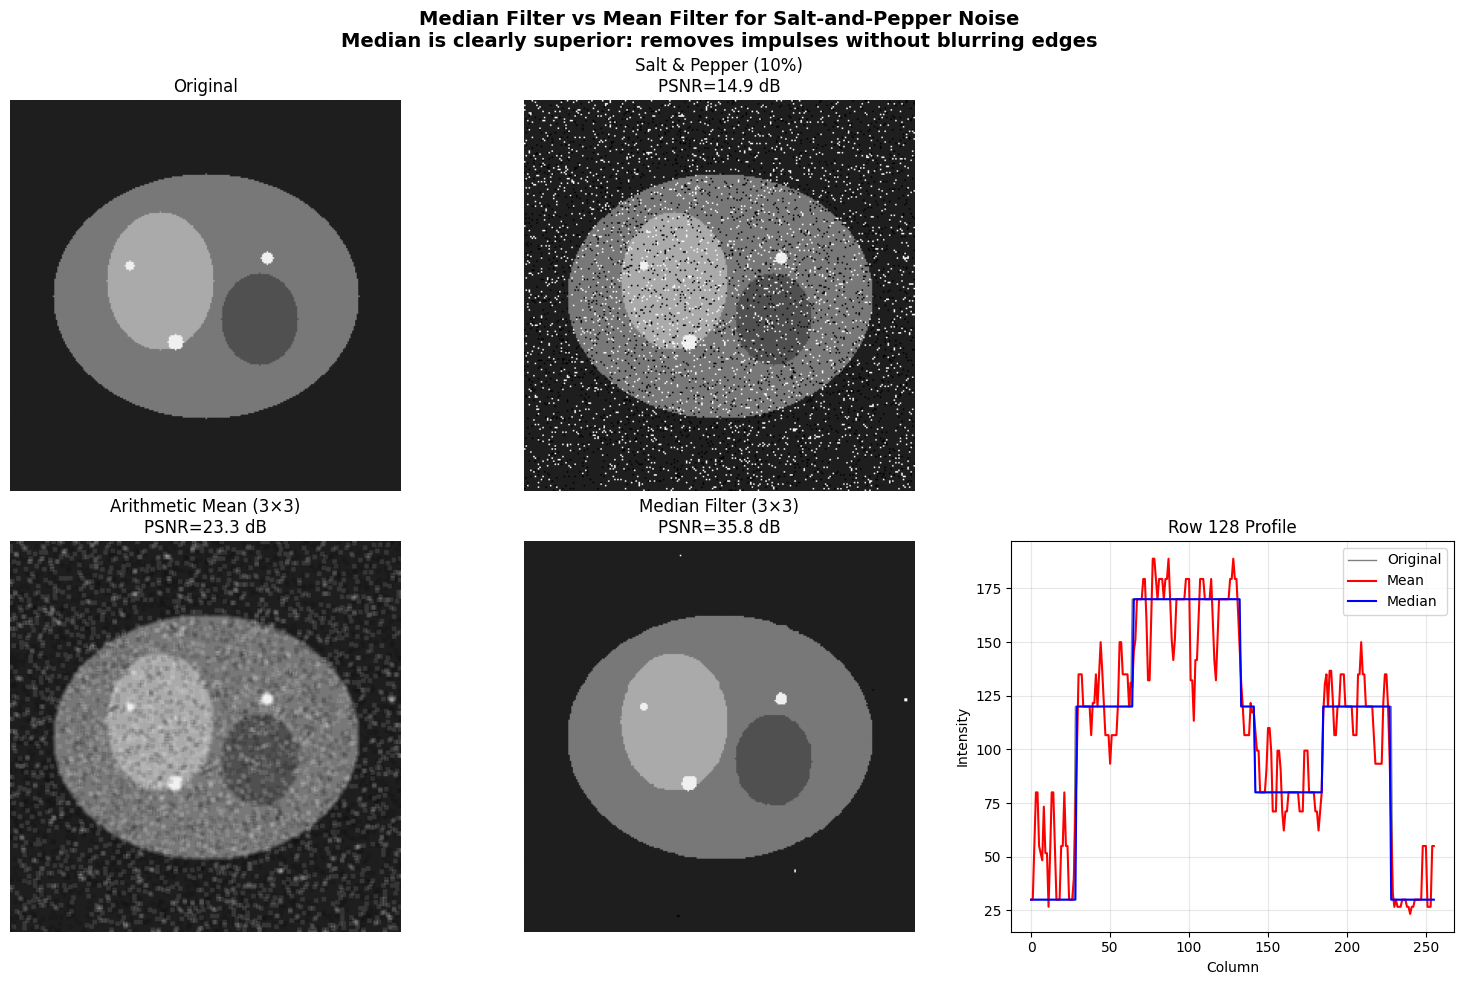

Mean filter SPREADS the impulses into gray smears.
Median filter REMOVES the impulses cleanly.


In [7]:
# Compare median filter vs arithmetic mean on salt-and-pepper noise

restored_median = median_filter(noisy_sp, 3)
restored_mean = arithmetic_mean_filter(noisy_sp, 3)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy_sp, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title(f'Salt & Pepper (10%)\nPSNR={compute_psnr(original, noisy_sp):.1f} dB', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(original, cmap='gray', vmin=0, vmax=255)  # placeholder
axes[0, 2].axis('off')
axes[0, 2].set_visible(False)

axes[1, 0].imshow(restored_mean, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title(f'Arithmetic Mean (3×3)\nPSNR={compute_psnr(original, restored_mean):.1f} dB', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(restored_median, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title(f'Median Filter (3×3)\nPSNR={compute_psnr(original, restored_median):.1f} dB', fontsize=12)
axes[1, 1].axis('off')

# Intensity profile comparison
row = 128
axes[1, 2].plot(original[row, :], 'k-', linewidth=1, alpha=0.5, label='Original')
axes[1, 2].plot(restored_mean[row, :], 'r-', linewidth=1.5, label='Mean')
axes[1, 2].plot(restored_median[row, :], 'b-', linewidth=1.5, label='Median')
axes[1, 2].set_title(f'Row {row} Profile', fontsize=12)
axes[1, 2].legend(fontsize=10)
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xlabel('Column')
axes[1, 2].set_ylabel('Intensity')

plt.suptitle('Median Filter vs Mean Filter for Salt-and-Pepper Noise\n'
             'Median is clearly superior: removes impulses without blurring edges',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Mean filter SPREADS the impulses into gray smears.")
print("Median filter REMOVES the impulses cleanly.")

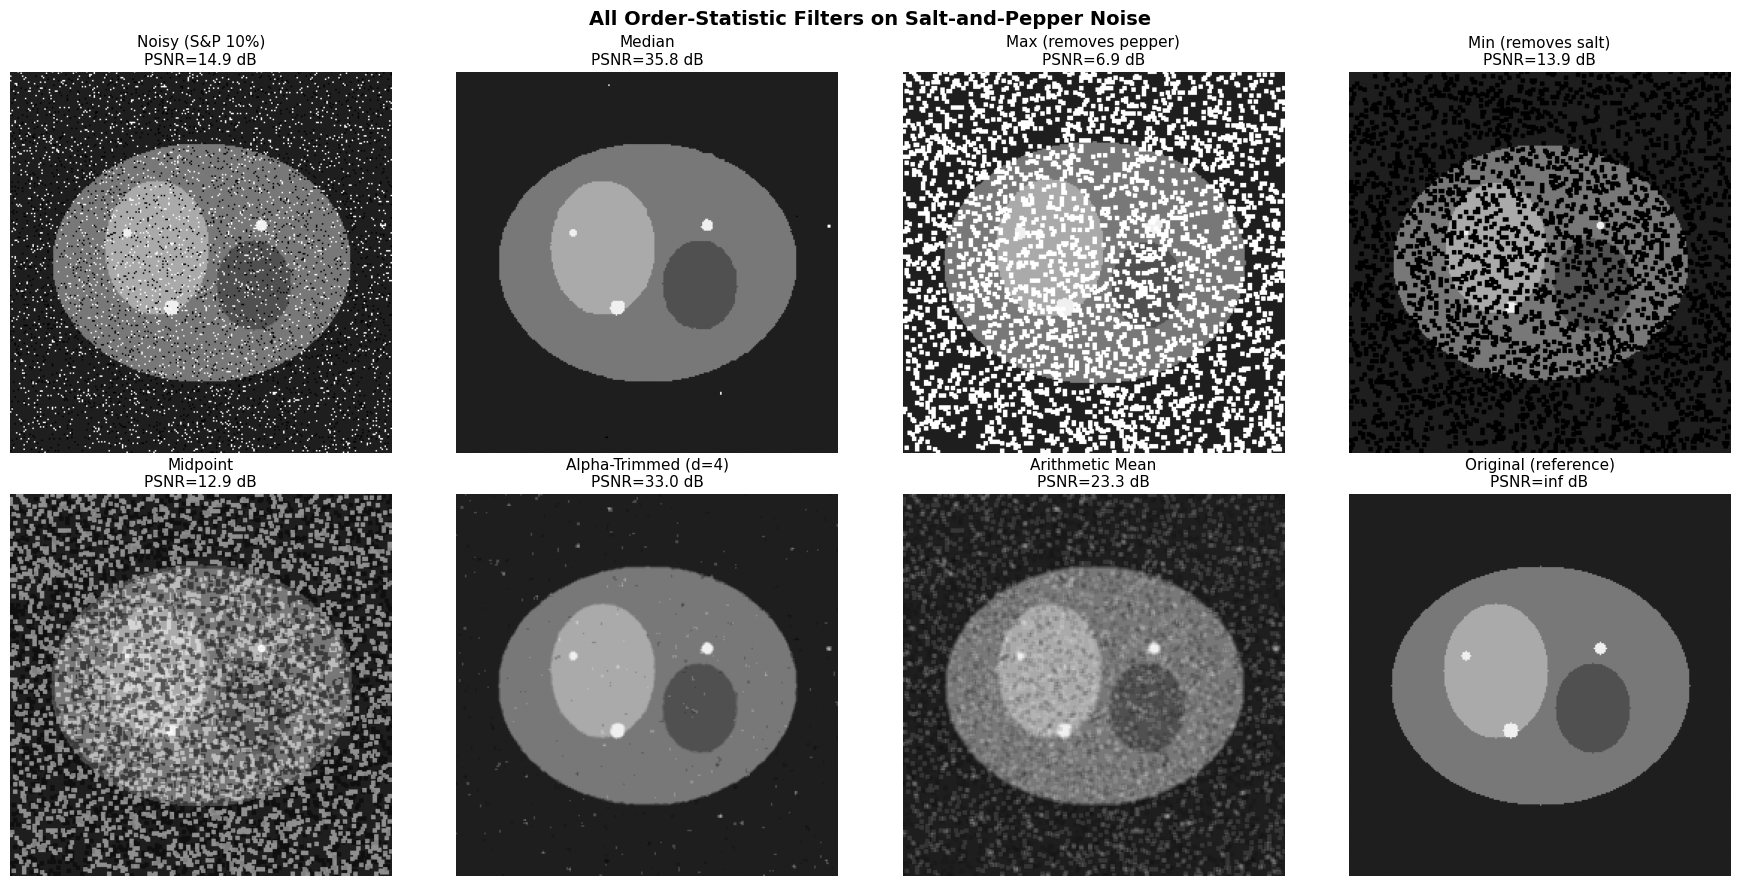

Best for S&P noise: Median > Alpha-Trimmed > Mean
Max filter: removes pepper (dark) but makes salt worse
Min filter: removes salt (bright) but makes pepper worse
Midpoint filter: vulnerable to extreme values


In [8]:
# All order-statistic filters comparison on salt-and-pepper noise

restored_max = max_filter(noisy_sp, 3)
restored_min = min_filter(noisy_sp, 3)
restored_mid = midpoint_filter(noisy_sp, 3)
restored_alpha = alpha_trimmed_mean_filter(noisy_sp, 3, d=4)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

filters = [
    (noisy_sp, 'Noisy (S&P 10%)'),
    (restored_median, 'Median'),
    (restored_max, 'Max (removes pepper)'),
    (restored_min, 'Min (removes salt)'),
]
filters2 = [
    (restored_mid, 'Midpoint'),
    (restored_alpha, 'Alpha-Trimmed (d=4)'),
    (restored_mean, 'Arithmetic Mean'),
    (original, 'Original (reference)'),
]

for i, (img, title) in enumerate(filters):
    psnr = compute_psnr(original, img)
    axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'{title}\nPSNR={psnr:.1f} dB', fontsize=11)
    axes[0, i].axis('off')

for i, (img, title) in enumerate(filters2):
    psnr = compute_psnr(original, img)
    axes[1, i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title(f'{title}\nPSNR={psnr:.1f} dB', fontsize=11)
    axes[1, i].axis('off')

plt.suptitle('All Order-Statistic Filters on Salt-and-Pepper Noise',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Best for S&P noise: Median > Alpha-Trimmed > Mean")
print("Max filter: removes pepper (dark) but makes salt worse")
print("Min filter: removes salt (bright) but makes pepper worse")
print("Midpoint filter: vulnerable to extreme values")

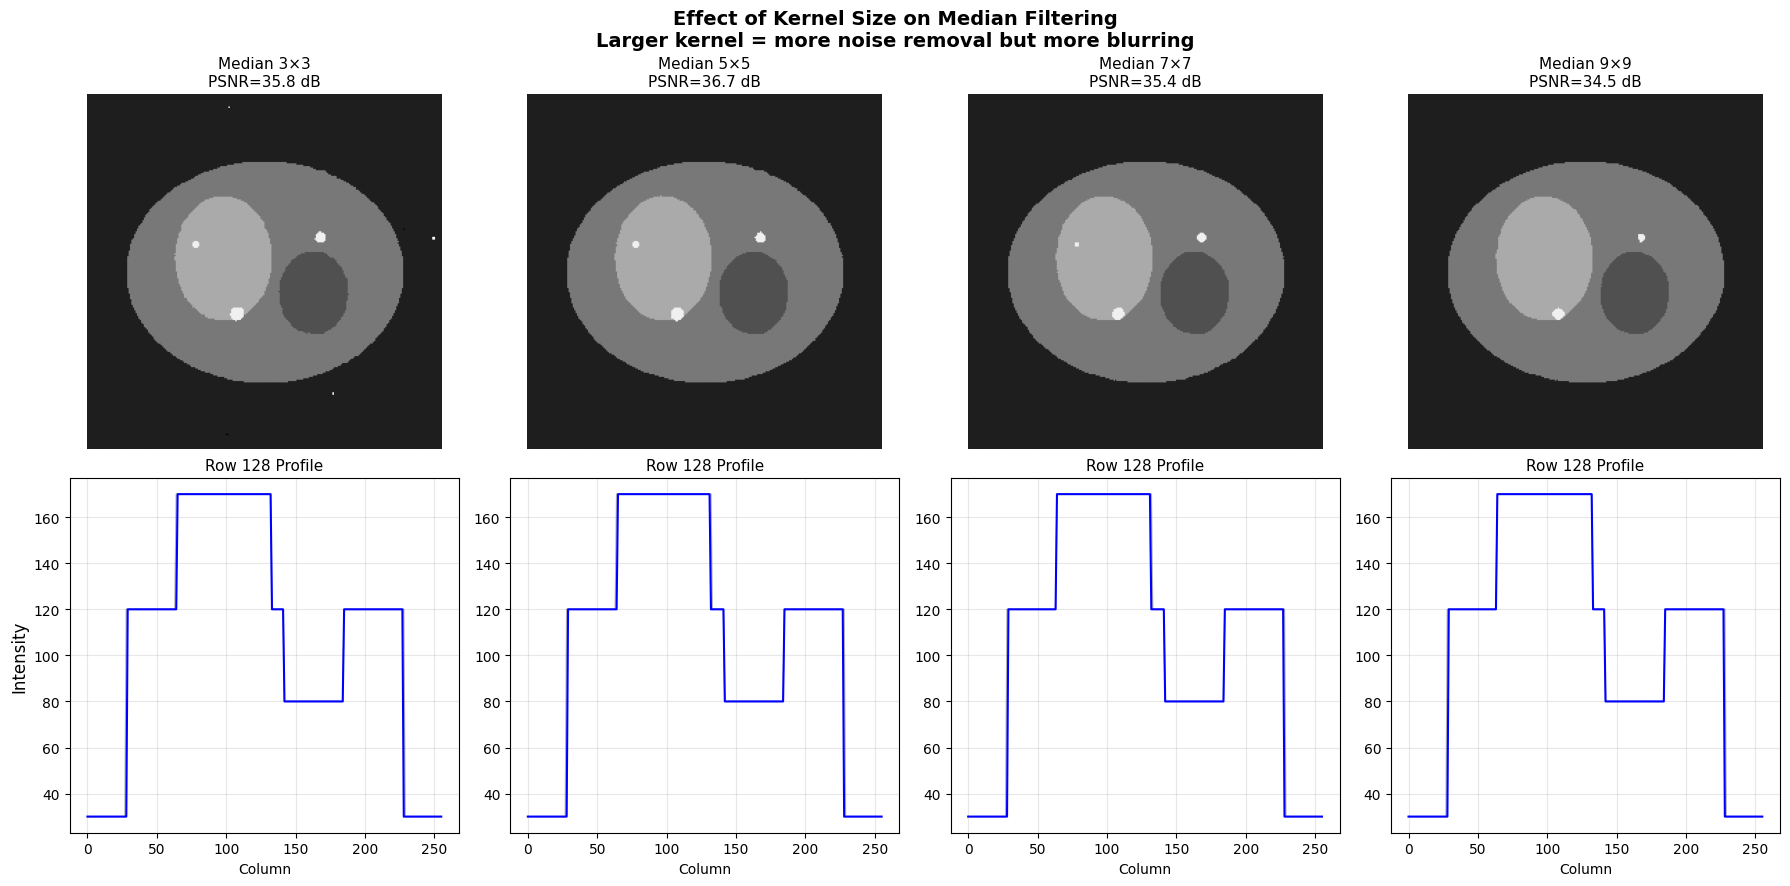

3×3: Good balance of noise removal and detail preservation
5×5: More smoothing, starting to lose fine details
7×7, 9×9: Heavy smoothing, edges start to round off


In [9]:
# Effect of kernel size on median filter
kernel_sizes = [3, 5, 7, 9]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, ks in enumerate(kernel_sizes):
    restored = median_filter(noisy_sp, ks)
    psnr = compute_psnr(original, restored)
    
    axes[0, i].imshow(restored, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'Median {ks}×{ks}\nPSNR={psnr:.1f} dB', fontsize=11)
    axes[0, i].axis('off')
    
    row = 128
    axes[1, i].plot(original[row, :], 'k-', alpha=0.3, linewidth=1, label='Original')
    axes[1, i].plot(restored[row, :], 'b-', linewidth=1.5)
    axes[1, i].set_title(f'Row {row} Profile', fontsize=11)
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].set_xlabel('Column')

axes[0, 0].set_ylabel('Filtered Image', fontsize=12)
axes[1, 0].set_ylabel('Intensity', fontsize=12)

plt.suptitle('Effect of Kernel Size on Median Filtering\n'
             'Larger kernel = more noise removal but more blurring',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("3×3: Good balance of noise removal and detail preservation")
print("5×5: More smoothing, starting to lose fine details")
print("7×7, 9×9: Heavy smoothing, edges start to round off")

---
## 4. Comprehensive Comparison: Which Filter for Which Noise?

| Noise Type | Best Filter | Why |
|---|---|---|
| **Gaussian** | Arithmetic mean, Geometric mean | Averaging reduces variance |
| **Uniform** | Arithmetic mean, Midpoint | Symmetric noise, averaging works |
| **Salt only** | Contraharmonic (Q<0), Min filter | Need to suppress bright outliers |
| **Pepper only** | Contraharmonic (Q>0), Max filter | Need to suppress dark outliers |
| **Salt & Pepper** | **Median**, Alpha-trimmed mean | Immune to extreme values |
| **Mixed (Gaussian+S&P)** | Alpha-trimmed mean | Handles both types |

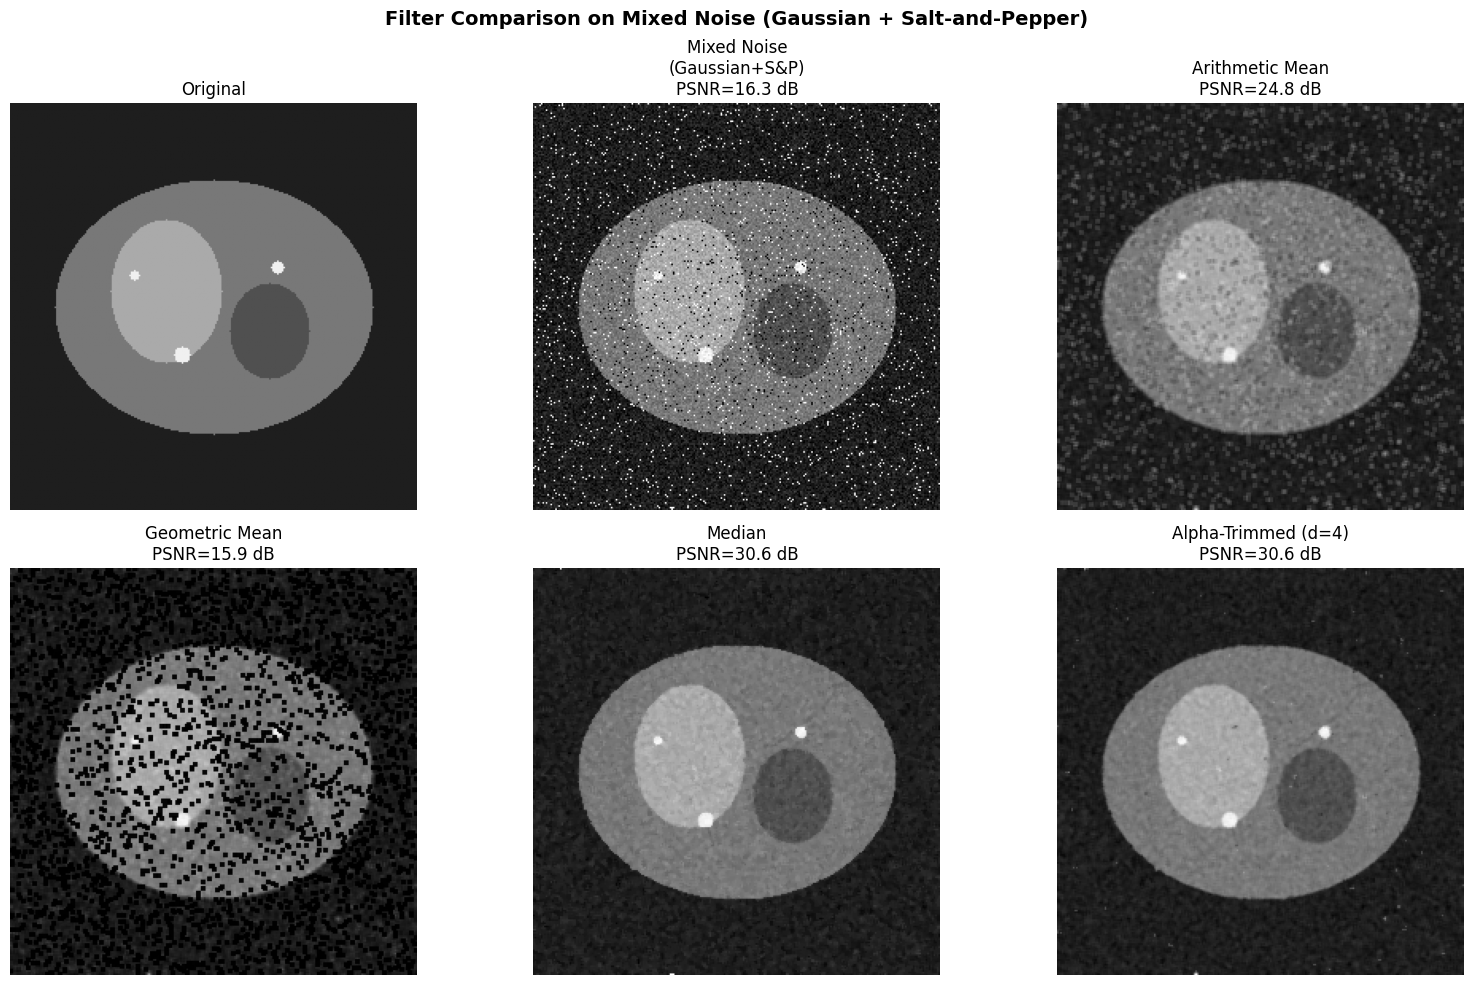

For mixed noise, the ALPHA-TRIMMED MEAN is often the best choice:
- It trims the extreme values (handling S&P noise like median)
- Then averages the remaining values (handling Gaussian noise like mean)


In [10]:
# Comprehensive comparison: different filters on different noise types

# Create mixed noise (Gaussian + salt-and-pepper)
np.random.seed(42)
noisy_mixed = add_gaussian_noise(original, sigma=15)
np.random.seed(99)
noisy_mixed = add_salt_pepper_noise(noisy_mixed, 0.03, 0.03)

# Apply various filters
results = {
    'Arithmetic Mean': arithmetic_mean_filter(noisy_mixed, 3),
    'Geometric Mean': geometric_mean_filter(noisy_mixed, 3),
    'Median': median_filter(noisy_mixed, 3),
    'Alpha-Trimmed (d=4)': alpha_trimmed_mean_filter(noisy_mixed, 3, d=4),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Top row
axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy_mixed, cmap='gray', vmin=0, vmax=255)
psnr_noisy = compute_psnr(original, noisy_mixed)
axes[0, 1].set_title(f'Mixed Noise\n(Gaussian+S&P)\nPSNR={psnr_noisy:.1f} dB', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(results['Arithmetic Mean'], cmap='gray', vmin=0, vmax=255)
psnr = compute_psnr(original, results['Arithmetic Mean'])
axes[0, 2].set_title(f'Arithmetic Mean\nPSNR={psnr:.1f} dB', fontsize=12)
axes[0, 2].axis('off')

axes[1, 0].imshow(results['Geometric Mean'], cmap='gray', vmin=0, vmax=255)
psnr = compute_psnr(original, results['Geometric Mean'])
axes[1, 0].set_title(f'Geometric Mean\nPSNR={psnr:.1f} dB', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(results['Median'], cmap='gray', vmin=0, vmax=255)
psnr = compute_psnr(original, results['Median'])
axes[1, 1].set_title(f'Median\nPSNR={psnr:.1f} dB', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(results['Alpha-Trimmed (d=4)'], cmap='gray', vmin=0, vmax=255)
psnr = compute_psnr(original, results['Alpha-Trimmed (d=4)'])
axes[1, 2].set_title(f'Alpha-Trimmed (d=4)\nPSNR={psnr:.1f} dB', fontsize=12)
axes[1, 2].axis('off')

plt.suptitle('Filter Comparison on Mixed Noise (Gaussian + Salt-and-Pepper)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("For mixed noise, the ALPHA-TRIMMED MEAN is often the best choice:")
print("- It trims the extreme values (handling S&P noise like median)")
print("- Then averages the remaining values (handling Gaussian noise like mean)")

---
## Summary

What we learned:

1. **Mean filters** replace each pixel with a mean-type computation over its neighborhood:
   - Arithmetic mean: simple average, blurs edges
   - Geometric mean: preserves detail better
   - Harmonic mean: good for salt noise, fails for pepper
   - Contraharmonic mean: $Q > 0$ removes pepper, $Q < 0$ removes salt

2. **Order-statistic filters** use ranking of pixel values:
   - **Median**: best for salt-and-pepper noise, preserves edges
   - Max/Min: remove pepper/salt respectively (one type only)
   - Midpoint: average of extremes, good for uniform noise
   - **Alpha-trimmed mean**: combination of median and mean, best for mixed noise

3. **No single filter works best for all noise types** — the choice depends on the noise model.

4. **Key trade-off**: More noise removal requires larger kernels, which causes more blurring and detail loss.

5. For salt-and-pepper noise: **always use median**, never arithmetic mean (mean spreads the impulses).